**Importing required Libraries**

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

**Uploading Dataset**

In [31]:
from google.colab import files

uploaded = files.upload()

Saving Wine_clust.csv to Wine_clust (1).csv


**Loading Dataset**

In [32]:
df = pd.read_csv('Wine_clust.csv')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


**Dataset Information**

In [33]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of Dataset:
(178, 13)

Column Names:
Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64


**Statistical Summary**

In [34]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



**Checking Missing Values**

In [35]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


**Correlation Heatmap**

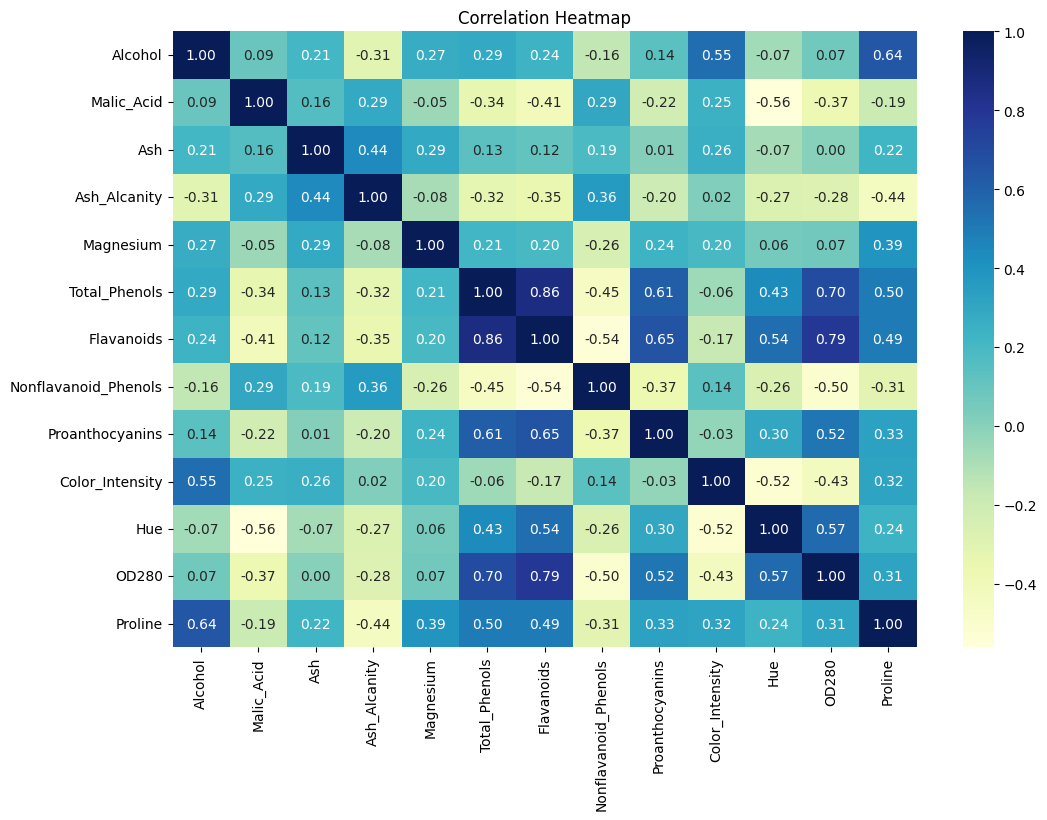

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

**Feature Scaling**



In [37]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


**Finding Optimal Clusters using Elbow Method**

In [38]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

**Plot**

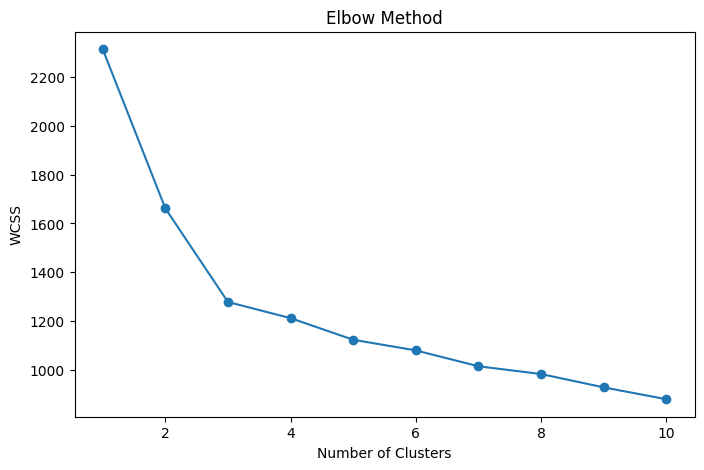

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

*The elbow point is observed at K = 3.
Therefore, the optimal number of clusters selected is 3.*

**K-Means Clustering**

In [40]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_df)

df['KMeans_Cluster'] = kmeans_labels

**Silhouette Score for K-Means**

In [41]:
score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.285


**PCA for Visualization**

In [42]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = kmeans_labels

**K-Means Cluster Visualization**

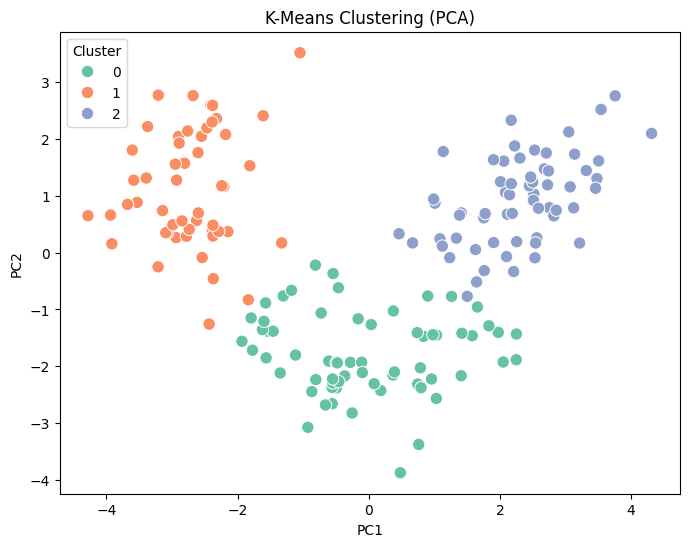

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    data=pca_df,
    s=80
)

plt.title("K-Means Clustering (PCA)")
plt.show()

**Hierarchical Clustering Dendrogram**

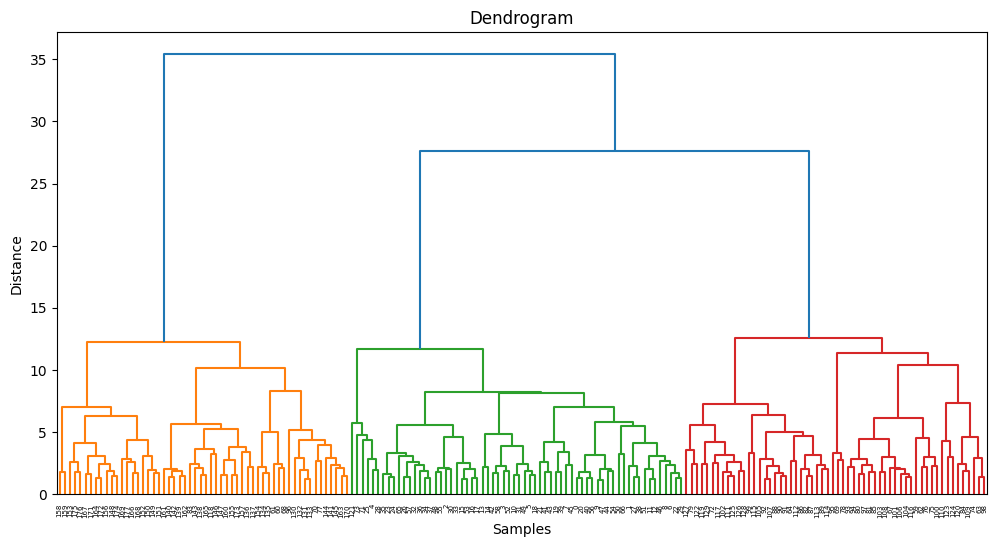

In [44]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(
        scaled_df,
        method='ward'
    )
)

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

*From the dendrogram, three major clusters can be observed.
Therefore, n_clusters = 3 is selected.*

**Agglomerative Clustering**

In [45]:
agglo = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agglo.fit_predict(
    scaled_df
)

df['Agglomerative_Cluster'] = agg_labels

**Silhouette Score**

In [46]:
agg_score = silhouette_score(
    scaled_df,
    agg_labels
)

print("Silhouette Score:", round(agg_score,3))

Silhouette Score: 0.277


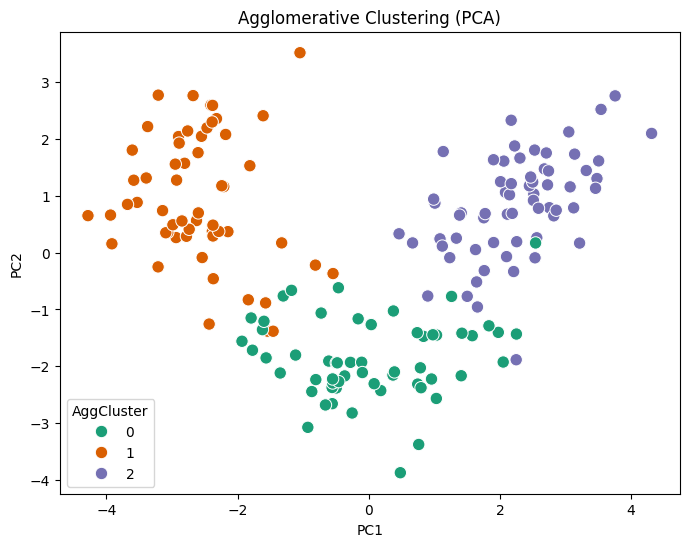

In [47]:
# Visualization

pca_df['AggCluster'] = agg_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='AggCluster',
    palette='Dark2',
    data=pca_df,
    s=80
)

plt.title("Agglomerative Clustering (PCA)")
plt.show()

**DBSCAN Clustering**

In [48]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    scaled_df
)

df['DBSCAN_Cluster'] = db_labels

# Number of clusters found

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

print("Number of Clusters:", n_clusters)
print("Cluster Labels:", set(db_labels))

Number of Clusters: 1
Cluster Labels: {np.int64(0), np.int64(-1)}


**DBSCAN Visualization**

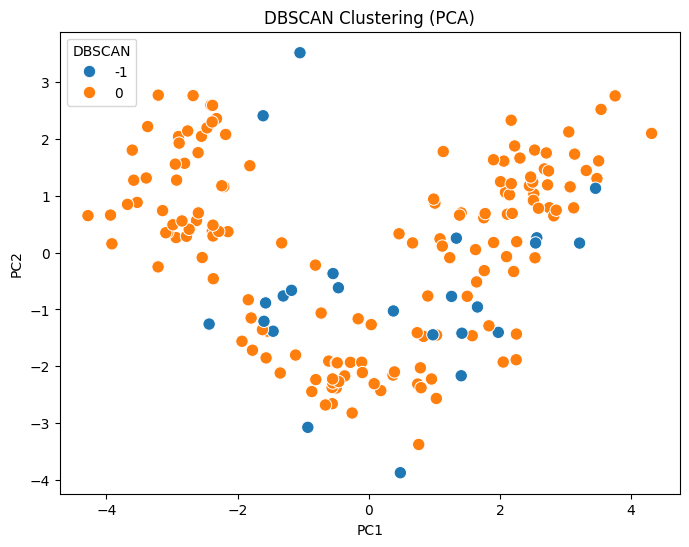

In [49]:


pca_df['DBSCAN'] = db_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN',
    palette='tab10',
    data=pca_df,
    s=80
)

plt.title("DBSCAN Clustering (PCA)")
plt.show()

In [50]:
# Comparing Models

comparison = pd.DataFrame({

    'Model':[
        'KMeans',
        'Agglomerative'
    ],

    'Silhouette Score':[
        silhouette_score(
            scaled_df,
            kmeans_labels
        ),

        silhouette_score(
            scaled_df,
            agg_labels
        )
    ]
})

comparison

,Model,Silhouette Score
0,KMeans,0.284859
1,Agglomerative,0.277444


In [51]:
# Best Model

comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Model,Silhouette Score
0,KMeans,0.284859
1,Agglomerative,0.277444


***CONCLUSION***

*Three clustering techniques were implemented on the Wine Dataset:*

          1.K-Means Clustering
          2.Agglomerative Hierarchical Clustering
          3.DBSCAN

*The optimal number of clusters for K-Means and Agglomerative Clustering was determined as 3 using the Elbow Method and Dendrogram respectively.*

*Cluster visualization was performed using PCA.*
*DBSCAN identified one cluster along with a few noise points.*

*Based on the Silhouette Score comparison:*

  *- K-Means: 0.284859*
  *- Agglomerative: 0.277444*

*K-Means achieved the highest Silhouette Score and is therefore considered the best clustering model for this dataset.*